# Pipe 01 & 02 — Ground State Finding & Konstruksi PES untuk H₂
**VQE · Ansatz UCCSD · Basis STO-3G · Qiskit 2.3.0**

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# --- Qiskit core
from qiskit.primitives import StatevectorEstimator

# --- qiskit-nature: driver & mapping
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.units import DistanceUnit

# --- qiskit-algorithms: VQE & exact reference
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP

warnings.filterwarnings("ignore")
print("Import OK")

Import OK


---
## Pipe 01 — Ground State Finding (H₂ @ equilibrium)

In [2]:
# === Inisialisasi parameter geometri H2 ===
R_EQ   = 0.735     # jarak ikatan ekuilibrium H2 (Angstrom)
BASIS  = "sto-3g"  # basis set minimal
CHARGE = 0         # muatan molekul
SPIN   = 0         # spin multiplisitas singlet (2S)

# --- Driver PySCF: mendefinisikan molekul H2 pada jarak ekuilibrium
driver_eq = PySCFDriver(
    atom=f"H .0 .0 .0; H .0 .0 {R_EQ}",  # dua atom H di sumbu z
    unit=DistanceUnit.ANGSTROM,
    basis=BASIS,
    charge=CHARGE,
    spin=SPIN
)

# Jalankan driver -> ElectronicStructureProblem
problem_eq = driver_eq.run()

print(f"Jumlah orbital spasial : {problem_eq.num_spatial_orbitals}")
print(f"Jumlah partikel        : {problem_eq.num_particles}")

Jumlah orbital spasial : 2
Jumlah partikel        : (1, 1)


In [3]:
# === Pemetaan Hamiltonians ke operator qubit ===
# ParityMapper + 2-qubit reduction -> H2 cukup 2 qubit
mapper = ParityMapper(num_particles=problem_eq.num_particles)

# Dapatkan operator Hamiltonias dari second quantization -> SparsePauliOp
hamiltonian_eq = mapper.map(problem_eq.second_q_ops()[0])

print(f"Jumlah qubit           : {hamiltonian_eq.num_qubits}")
print(f"Jumlah suku Pauli      : {len(hamiltonian_eq)}")
print("\nHamiltonian (SparsePauliOp):")
print(hamiltonian_eq)

Jumlah qubit           : 2
Jumlah suku Pauli      : 5

Hamiltonian (SparsePauliOp):
SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-1.05237325+0.j,  0.39793742+0.j, -0.39793742+0.j, -0.0112801 +0.j,
  0.1809312 +0.j])


Jumlah parameter ansatz : 3
Jumlah qubit ansatz     : 2


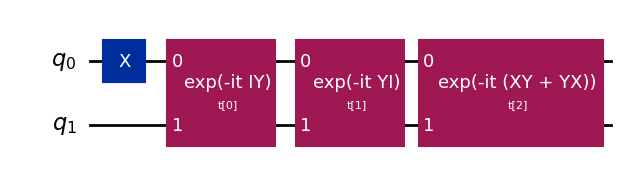

In [4]:
# === Ansatz UCCSD + Initial State Hartree-Fock ===

# Initial state HF: ground state klasik sebagai titik awal VQE
hf_state = HartreeFock(
    num_spatial_orbitals=problem_eq.num_spatial_orbitals,
    num_particles=problem_eq.num_particles,
    qubit_mapper=mapper
)

# Ansatz UCCSD: Unitary Coupled Cluster Single & Double excitations
ansatz = UCCSD(
    num_spatial_orbitals=problem_eq.num_spatial_orbitals,
    num_particles=problem_eq.num_particles,
    qubit_mapper=mapper,
    initial_state=hf_state
)

print(f"Jumlah parameter ansatz : {ansatz.num_parameters}")
print(f"Jumlah qubit ansatz     : {ansatz.num_qubits}")
ansatz.decompose().draw("mpl", style="iqp", fold=-1)

In [5]:
# === Setup VQE (Variational Quantum Eigensolver) ===

# Callback untuk merekam nilai energi setiap iterasi
energy_history = []  # menyimpan energi per iterasi optimizer

def callback(nfev, x, fx, dx):
    # fx: energi pada iterasi ini
    energy_history.append(float(fx))

# Estimator V2 (Qiskit 2.x) - menghitung nilai ekspektasi <psi|H|psi>
estimator = StatevectorEstimator()

# Optimizer SLSQP: gradient-based, cocok untuk VQE dengan sedikit parameter
optimizer = SLSQP(maxiter=300)

# Inisialisasi VQE
vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback,
    initial_point=np.zeros(ansatz.num_parameters)  # mulai dari HF (theta=0)
)

print("VQE siap dijalankan")

VQE siap dijalankan


In [6]:
# === Jalankan VQE + Exact Reference (NumPy) ===

# VQE: minimisasi energi variasional
vqe_result = vqe.compute_minimum_eigenvalue(hamiltonian_eq)
E_vqe = vqe_result.eigenvalue.real

# Exact solver: diagonalisasi matriks Hamiltonians langsung (reference FCI)
exact_solver  = NumPyMinimumEigensolver()
exact_result  = exact_solver.compute_minimum_eigenvalue(hamiltonian_eq)
E_exact       = exact_result.eigenvalue.real

# Energi total dengan nuclear repulsion
nuclear_repulsion = problem_eq.nuclear_repulsion_energy

print(f"E_VQE  (electronic)   : {E_vqe:.6f} Ha")
print(f"E_Exact (electronic)  : {E_exact:.6f} Ha")
print(f"Nuclear repulsion     : {nuclear_repulsion:.6f} Ha")
print(f"E_VQE  (total)        : {E_vqe + nuclear_repulsion:.6f} Ha")
print(f"E_Exact (total)       : {E_exact + nuclear_repulsion:.6f} Ha")
print(f"Error (chemical acc.) : {abs(E_vqe - E_exact)*1000:.4f} mHa")
print(f"\nParameter optimal     : {vqe_result.optimal_point}")

E_VQE  (electronic)   : -1.857275 Ha
E_Exact (electronic)  : -1.857275 Ha
Nuclear repulsion     : 0.719969 Ha
E_VQE  (total)        : -1.137306 Ha
E_Exact (total)       : -1.137306 Ha
Error (chemical acc.) : 0.0000 mHa

Parameter optimal     : [-3.97191696e-08  1.01078645e-08 -1.11762569e-01]


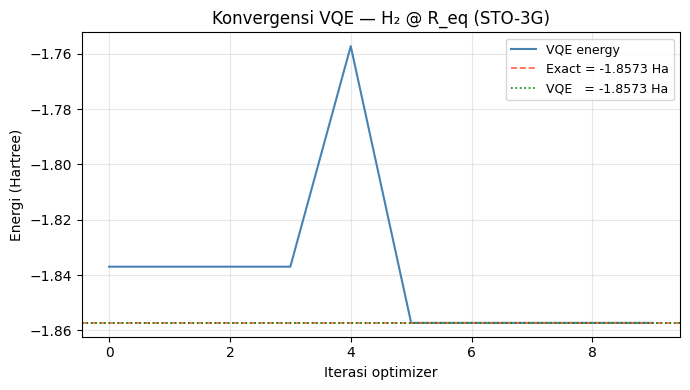

Konvergen dalam 10 iterasi


In [7]:
# Visualisasi konvergensi VQE
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(energy_history, color="steelblue", linewidth=1.5, label="VQE energy")
ax.axhline(E_exact, color="tomato", linestyle="--", linewidth=1.2, label=f"Exact = {E_exact:.4f} Ha")
ax.axhline(E_vqe,   color="green",  linestyle=":",  linewidth=1.2, label=f"VQE   = {E_vqe:.4f} Ha")

ax.set_xlabel("Iterasi optimizer")
ax.set_ylabel("Energi (Hartree)")
ax.set_title("Konvergensi VQE — H₂ @ R_eq (STO-3G)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Konvergen dalam {len(energy_history)} iterasi")

---
## Pipe 02 — Konstruksi PES (Potential Energy Surface)
Grid sweep R_min → R_max · Parameter transfer VQE (warm-starting) · Interpolasi CubicSpline

In [8]:
# === Inisialisasi grid jarak ikatan untuk PES ===
R_MIN   = 0.30   # Angstrom — compressed region (classically forbidden)
R_MAX   = 3.00   # Angstrom — dissociation region
N_GRID  = 25     # jumlah titik grid (lebih rapat = lebih halus)

# Grid jarak ikatan H-H (linspace)
r_grid = np.linspace(R_MIN, R_MAX, N_GRID)

# Storage hasil PES
energies_vqe   = []   # energi total VQE  (electronic + nuclear)
energies_exact = []   # energi total exact (referensi FCI)
params_store   = []   # menyimpan parameter optimal tiap geometri

print(f"Grid PES: {N_GRID} titik dari {R_MIN} Å hingga {R_MAX} Å")
print(f"Titik ekuilibrium H2: {R_EQ} Å")

Grid PES: 25 titik dari 0.3 Å hingga 3.0 Å
Titik ekuilibrium H2: 0.735 Å


In [9]:
# === Sweep PES dengan warm-starting (parameter transfer) ===
# Strategi: parameter optimal dari geometri R_i digunakan sebagai
# titik awal (initial_point) untuk VQE di geometri R_{i+1}
# -> mempercepat konvergensi dan mengurangi jumlah iterasi

# Parameter awal: theta=0 (setara Hartree-Fock)
current_params = np.zeros(ansatz.num_parameters)

for i, r in enumerate(r_grid):
    # --- Buat molekul H2 pada jarak ikatan r
    driver_r = PySCFDriver(
        atom=f"H .0 .0 .0; H .0 .0 {r}",
        unit=DistanceUnit.ANGSTROM,
        basis=BASIS, charge=CHARGE, spin=SPIN
    )
    problem_r = driver_r.run()

    # --- Hamiltonians qubit pada geometri r
    mapper_r     = ParityMapper(num_particles=problem_r.num_particles)
    hamiltonian_r = mapper_r.map(problem_r.second_q_ops()[0])
    nuc_rep       = problem_r.nuclear_repulsion_energy  # repulsi inti

    # --- Ansatz UCCSD pada geometri r
    hf_r = HartreeFock(
        num_spatial_orbitals=problem_r.num_spatial_orbitals,
        num_particles=problem_r.num_particles,
        qubit_mapper=mapper_r
    )
    ansatz_r = UCCSD(
        num_spatial_orbitals=problem_r.num_spatial_orbitals,
        num_particles=problem_r.num_particles,
        qubit_mapper=mapper_r,
        initial_state=hf_r
    )

    # --- VQE dengan warm-starting: gunakan current_params sebagai initial_point
    vqe_r = VQE(
        estimator=StatevectorEstimator(),
        ansatz=ansatz_r,
        optimizer=SLSQP(maxiter=300),
        initial_point=current_params  # transfer parameter dari geometri sebelumnya
    )
    result_r  = vqe_r.compute_minimum_eigenvalue(hamiltonian_r)
    E_elec_r  = result_r.eigenvalue.real
    E_total_r = E_elec_r + nuc_rep     # energi total = elektronik + repulsi inti

    # --- Exact reference (NumPy diagonalization)
    exact_r   = NumPyMinimumEigensolver().compute_minimum_eigenvalue(hamiltonian_r)
    E_ex_tot  = exact_r.eigenvalue.real + nuc_rep

    # --- Simpan hasil & update params untuk warm-starting berikutnya
    energies_vqe.append(E_total_r)
    energies_exact.append(E_ex_tot)
    params_store.append(result_r.optimal_point.copy())
    current_params = result_r.optimal_point.copy()  # warm-start ke titik berikutnya

    print(f"[{i+1:2d}/{N_GRID}] R={r:.3f} Å | E_VQE={E_total_r:.5f} | E_Exact={E_ex_tot:.5f} Ha")

energies_vqe   = np.array(energies_vqe)
energies_exact = np.array(energies_exact)
print("\nSweep PES selesai!")

[ 1/25] R=0.300 Å | E_VQE=-0.60180 | E_Exact=-0.60180 Ha
[ 2/25] R=0.412 Å | E_VQE=-0.93840 | E_Exact=-0.93840 Ha
[ 3/25] R=0.525 Å | E_VQE=-1.07591 | E_Exact=-1.07591 Ha
[ 4/25] R=0.637 Å | E_VQE=-1.12728 | E_Exact=-1.12728 Ha
[ 5/25] R=0.750 Å | E_VQE=-1.13712 | E_Exact=-1.13712 Ha
[ 6/25] R=0.863 Å | E_VQE=-1.12657 | E_Exact=-1.12657 Ha
[ 7/25] R=0.975 Å | E_VQE=-1.10634 | E_Exact=-1.10634 Ha
[ 8/25] R=1.087 Å | E_VQE=-1.08200 | E_Exact=-1.08200 Ha
[ 9/25] R=1.200 Å | E_VQE=-1.05674 | E_Exact=-1.05674 Ha
[10/25] R=1.312 Å | E_VQE=-1.03261 | E_Exact=-1.03261 Ha
[11/25] R=1.425 Å | E_VQE=-1.01090 | E_Exact=-1.01090 Ha
[12/25] R=1.538 Å | E_VQE=-0.99233 | E_Exact=-0.99233 Ha
[13/25] R=1.650 Å | E_VQE=-0.97713 | E_Exact=-0.97713 Ha
[14/25] R=1.763 Å | E_VQE=-0.96515 | E_Exact=-0.96515 Ha
[15/25] R=1.875 Å | E_VQE=-0.95603 | E_Exact=-0.95603 Ha
[16/25] R=1.988 Å | E_VQE=-0.94927 | E_Exact=-0.94927 Ha
[17/25] R=2.100 Å | E_VQE=-0.94437 | E_Exact=-0.94437 Ha
[18/25] R=2.212 Å | E_VQE=-0.94

In [10]:
# === Interpolasi CubicSpline pada PES ===
# Menghaluskan kurva PES dari titik-titik diskrit grid

r_fine = np.linspace(R_MIN, R_MAX, 300)   # grid rapat untuk kurva halus

cs_vqe   = CubicSpline(r_grid, energies_vqe)    # spline VQE
cs_exact = CubicSpline(r_grid, energies_exact)  # spline exact

# Estimasi titik minimum (jarak ekuilibrium dari PES)
r_min_vqe   = r_fine[np.argmin(cs_vqe(r_fine))]
r_min_exact = r_fine[np.argmin(cs_exact(r_fine))]

print(f"R_eq dari PES VQE   : {r_min_vqe:.4f} Å")
print(f"R_eq dari PES Exact : {r_min_exact:.4f} Å")
print(f"Referensi literatur  : {R_EQ:.4f} Å")

R_eq dari PES VQE   : 0.7334 Å
R_eq dari PES Exact : 0.7334 Å
Referensi literatur  : 0.7350 Å


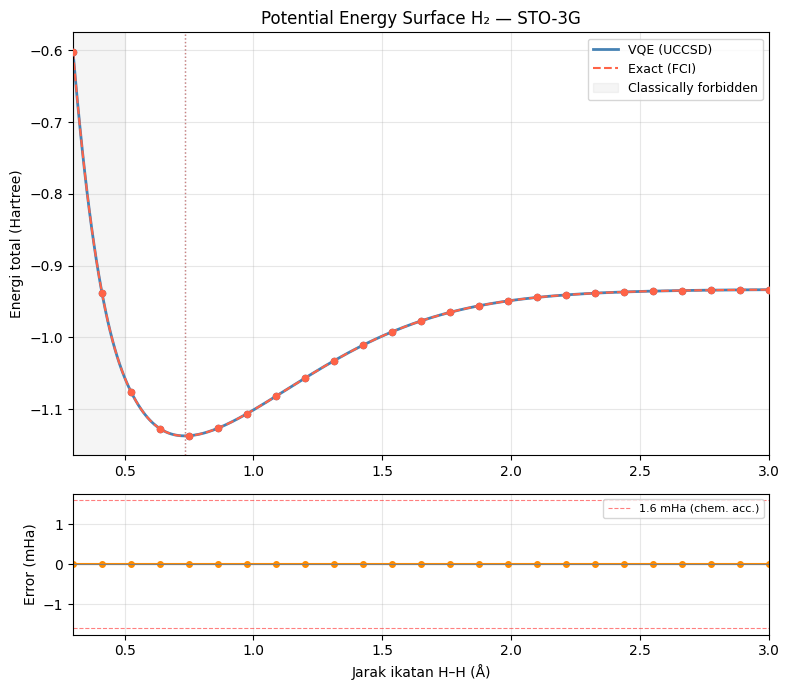

In [11]:
# Visualisasi PES H2: VQE vs Exact
fig, axes = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={"height_ratios": [3, 1]})

# --- Panel atas: kurva PES
ax = axes[0]
ax.plot(r_fine, cs_vqe(r_fine),   color="steelblue", lw=2,   label="VQE (UCCSD)")
ax.plot(r_fine, cs_exact(r_fine), color="tomato",    lw=1.5, linestyle="--", label="Exact (FCI)")

# Titik data grid
ax.scatter(r_grid, energies_vqe,   s=20, color="steelblue", zorder=5)
ax.scatter(r_grid, energies_exact, s=20, color="tomato",    zorder=5)

# Tandai titik minimum
ax.axvline(r_min_vqe,   color="steelblue", linestyle=":", alpha=0.6, lw=1)
ax.axvline(r_min_exact, color="tomato",    linestyle=":", alpha=0.6, lw=1)

# Tandai region classically forbidden (R < ~0.5 Å)
ax.axvspan(R_MIN, 0.50, alpha=0.08, color="gray", label="Classically forbidden")

ax.set_ylabel("Energi total (Hartree)")
ax.set_title("Potential Energy Surface H₂ — STO-3G")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(R_MIN, R_MAX)

# --- Panel bawah: error VQE vs exact (mHa)
ax2 = axes[1]
error_mha = (energies_vqe - energies_exact) * 1000  # konversi ke milli-Hartree
ax2.plot(r_grid, error_mha, color="darkorange", lw=1.5, marker="o", markersize=4)
ax2.axhline(0,    color="gray", lw=0.8, linestyle="-")
ax2.axhline(1.6,  color="red",  lw=0.8, linestyle="--", alpha=0.5, label="1.6 mHa (chem. acc.)")
ax2.axhline(-1.6, color="red",  lw=0.8, linestyle="--", alpha=0.5)
ax2.set_xlabel("Jarak ikatan H–H (Å)")
ax2.set_ylabel("Error (mHa)")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(R_MIN, R_MAX)

plt.tight_layout()
plt.show()

In [12]:
# === Ringkasan hasil Pipe 01 & 02 ===
print("=" * 55)
print("  RINGKASAN PIPE 01 — Ground State Finding (H2 @ Req)")
print("=" * 55)
print(f"  Ansatz         : UCCSD")
print(f"  Basis          : STO-3G")
print(f"  Qubit          : {hamiltonian_eq.num_qubits} (ParityMapper + 2-qubit reduction)")
print(f"  Parameter      : {ansatz.num_parameters}")
print(f"  E_VQE total    : {E_vqe + problem_eq.nuclear_repulsion_energy:.6f} Ha")
print(f"  E_Exact total  : {E_exact + problem_eq.nuclear_repulsion_energy:.6f} Ha")
print(f"  Error          : {abs(E_vqe - E_exact)*1000:.4f} mHa")
print()
print("=" * 55)
print("  RINGKASAN PIPE 02 — Konstruksi PES")
print("=" * 55)
print(f"  Grid           : {N_GRID} titik [{R_MIN} – {R_MAX}] Å")
print(f"  Strategi       : Warm-starting (parameter transfer)")
print(f"  Interpolasi    : CubicSpline")
print(f"  R_eq VQE       : {r_min_vqe:.4f} Å")
print(f"  R_eq Exact     : {r_min_exact:.4f} Å")
print(f"  Max |error|    : {np.max(np.abs(error_mha)):.4f} mHa")
print(f"  Mean |error|   : {np.mean(np.abs(error_mha)):.4f} mHa")

  RINGKASAN PIPE 01 — Ground State Finding (H2 @ Req)
  Ansatz         : UCCSD
  Basis          : STO-3G
  Qubit          : 2 (ParityMapper + 2-qubit reduction)
  Parameter      : 3
  E_VQE total    : -1.137306 Ha
  E_Exact total  : -1.137306 Ha
  Error          : 0.0000 mHa

  RINGKASAN PIPE 02 — Konstruksi PES
  Grid           : 25 titik [0.3 – 3.0] Å
  Strategi       : Warm-starting (parameter transfer)
  Interpolasi    : CubicSpline
  R_eq VQE       : 0.7334 Å
  R_eq Exact     : 0.7334 Å
  Max |error|    : 0.0000 mHa
  Mean |error|   : 0.0000 mHa
